<center>

##
## Diabetes Prediction Dataset EDA & Preprocessing Pipeline

**Dataset:** Diabetes Prediction Dataset (iammustafatz) - Kaggle

**Author:** Tamika Andrews

</center>



---
### About this notebook
This notebook covers two stages of the project pipeline for the Diabetes Prediction dataset:

1. **Exploratory Data Analysis (EDA)** — understanding the structure, distributions, class balance, and feature relationships in the raw dataset before any modifications are made.
2. **Preprocessing Pipeline** — cleaning, encoding, resampling, and splitting the data into training and test sets ready for modelling.

The dataset contains medical and demographic data for 100,000 patients. The target variable is `diabetes` - a binary label where **1 = diabetic** and **0 = not diabetic**.

This is one of three datasets used in our comparative study.

---



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:
!git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git
os.chdir("Predicting-Type-2-Diabetes")

path = "data/raw/diabetes_prediction_dataset.csv"
try:
    df = pd.read_csv(path)
    print(" Diabetes Prediction Dataset loaded successfully")
except Exception as e:
    print(f"Failed to load dataset: {e}")

df.head(10)


Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 46 (delta 13), reused 13 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 3.28 MiB | 2.76 MiB/s, done.
Resolving deltas: 100% (13/13), done.
 Diabetes Prediction Dataset loaded successfully


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [14]:
print("-" * 30)
print(" Shape & Data Types")
print("-" * 30)
print(f"\n  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)

------------------------------
 Shape & Data Types
------------------------------

  Rows    : 100,000
  Columns : 9

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [29]:
print("-" * 50)
print(" Categorical/Numerical Columns & Null Values")
print("-" * 50)

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nCategorical Columns:")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")

print(f"\nNumerical Columns:")
print(df[numerical_cols].describe().round(2))

print(f"\nNull Values:")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

--------------------------------------------------
 Categorical Columns & Null Values
--------------------------------------------------

Categorical Columns:
  gender: ['Female' 'Male' 'Other']
  smoking_history: ['never' 'No Info' 'current' 'former' 'ever' 'not current']

Numerical Columns:
             age  hypertension  heart_disease        bmi  HbA1c_level  \
count  100000.00     100000.00      100000.00  100000.00    100000.00   
mean       41.89          0.07           0.04      27.32         5.53   
std        22.52          0.26           0.19       6.64         1.07   
min         0.08          0.00           0.00      10.01         3.50   
25%        24.00          0.00           0.00      23.63         4.80   
50%        43.00          0.00           0.00      27.32         5.80   
75%        60.00          0.00           0.00      29.58         6.20   
max        80.00          1.00           1.00      95.69         9.00   

       blood_glucose_level   diabetes  
count   

In [19]:
print("-" * 31)
print(" Class Distribution")
print("-" * 31)

class_counts = df["diabetes"].value_counts()
class_pct = df["diabetes"].value_counts(normalize=True) * 100

print(pd.DataFrame({"Count": class_counts, "Percentage (%)": class_pct.round(2)}))

-------------------------------
 Class Distribution
-------------------------------
          Count  Percentage (%)
diabetes                       
0         91500            91.5
1          8500             8.5


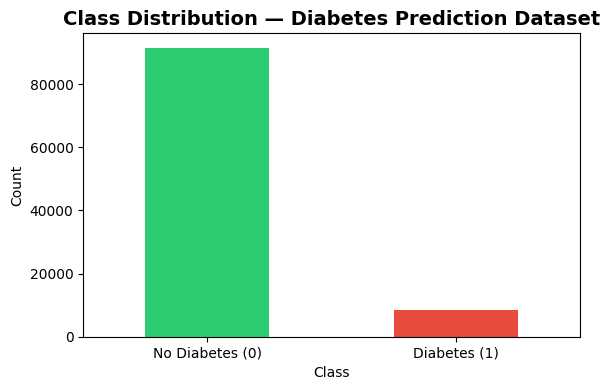

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
df["diabetes"].value_counts().plot(kind="bar", color=["#2ECC71", "#E74C3C"], ax=ax)

ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_title("Class Distribution — Diabetes Prediction Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("class_distribution_diabetes_prediction.png", dpi=150)
plt.show()

In [24]:
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

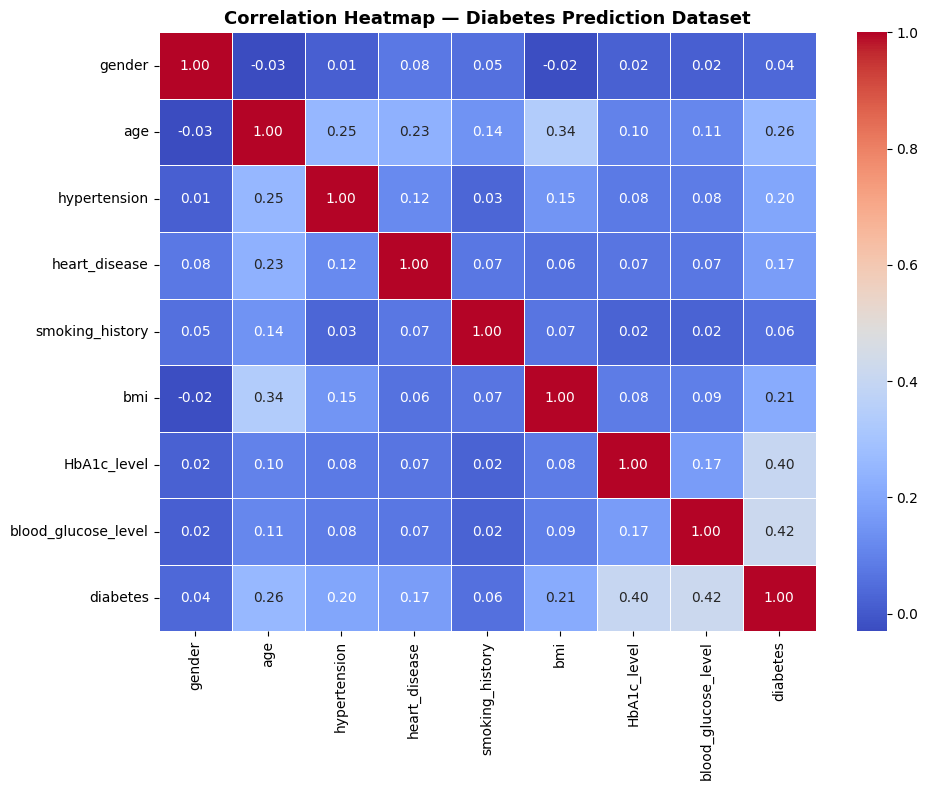

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Diabetes Prediction Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_diabetes_prediction.png', dpi=150)
plt.show()


gender:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

smoking_history:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


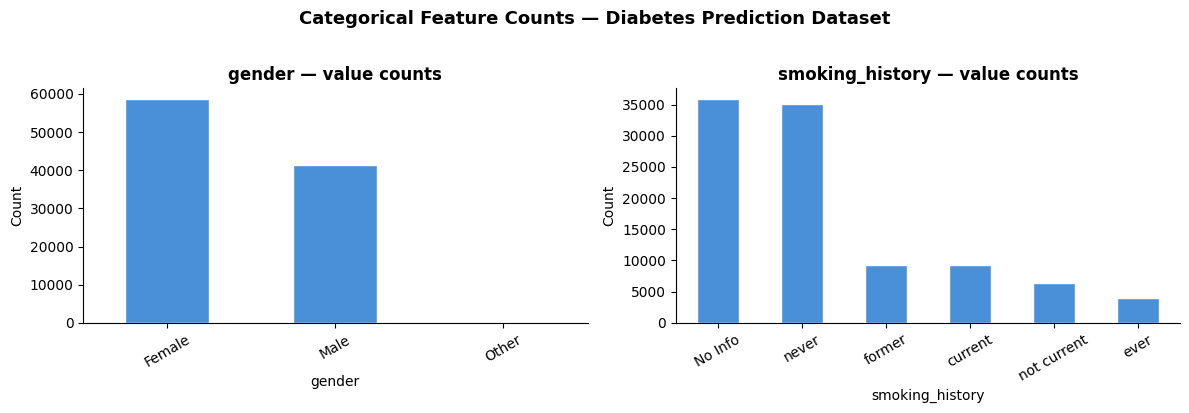

In [28]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(12, 4))

for ax, col in zip(axes, categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#4A90D9', edgecolor='white')
    ax.set_title(f'{col} — value counts', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Categorical Feature Counts — Diabetes Prediction Dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_counts_diabetes_prediction.png', dpi=150)
plt.show()